this notebook loads the EMG data, and plots an average time-frequency plot for each EMG channel in a [-0.5s 0.5s] window around each button press Baseline corrected by the average power in each frequency band during the [-1 0s] window of the EMG data.

In [ ]:
# import toolboxes 

import h5py
import mne 
import numpy as np
import matplotlib.pyplot as plt
import os

In [ ]:
# locate data files

subject_folder = "//rdp.arc.ucl.ac.uk/ritd-ag-project-rd01pz-dbush99/Katja Button Press Data"
button_press_folder = "/beh_data/s05"
EMG_file = "/s05/Subject5_spm_mne-epo.fif"

BP_filepath_1 = subject_folder + button_press_folder + "/behDataMEG.mat"
BP_filepath_2 = subject_folder + button_press_folder + "/targetMEG.mat"
EMG_filepath = subject_folder + EMG_file 


In [ ]:
# load button press data

with h5py.File(BP_filepath_1, 'r') as f:
    timings = f['A/timing'][:]
    presses = f['A/press'][:]
timings = timings.T
presses = presses.T

with h5py.File(BP_filepath_2, 'r') as f:
    cuedur = f['T/cueDur'][:]
cuedur = cuedur.T

press_times = (timings + np.tile(cuedur,5)) / 1000

print(f'press times array: {press_times}')
print('\n')
print(f'press times shape: {press_times.shape}')
print('\n')
print(f'press sequence array:{presses}')
print('\n')
print(f'presses array shape {presses.shape}')


In [ ]:
# load all linked split FIF files as one Epochs object
EMG_data = mne.read_epochs(EMG_filepath, preload=True)


In [ ]:
# check the info of the loaded EMG data

print(EMG_data.info)
print(f'Channel Names: {EMG_data.info["ch_names"]}')

In [ ]:
# isolate button press channel and EMG channels

BP_channel = EMG_data.get_data(picks='UPPT002')[:,0,:]
EMG_channels = EMG_data.get_data(picks=['EEG057','EEG058','EEG059','EEG060'])
print(f'Button press channel shape: {BP_channel.shape}')
print(f'EMG channels shape: {EMG_channels.shape}')

In [ ]:
# change channel signal back by -2.8 seconds to align with button press times. 

BP_channel = np.roll(BP_channel, -int(2.8 * EMG_data.info['sfreq']), axis=1)

In [ ]:
# checking if the list of press times for each trial match the signal in UPPT002 channel


def UPPT002_plot(trial1,trial2):

    plt.figure(figsize=(12, 6))
    plt.title('Trial Period vs. Channel Signal')
    plt.axis('off')

    plt.subplot(2,1,1)
    plt.plot(EMG_data.times, BP_channel[trial1],
            color='black',
            alpha=0.7,
            )

    for idx,pt in enumerate(press_times[trial1]):
        plt.axvline(
            x=pt,
            color='r',
            linestyle='--',
            alpha=0.7,
            )
    plt.ylabel('Channel Signal (V)')
    plt.xlim([0, 10])
    plt.legend(['Channel signal'],['Button Press'])
    plt.grid(alpha=0.3,which='both',axis='both')

    plt.subplot(2,1,2)
    plt.plot(EMG_data.times, BP_channel[trial2],
            color='black',
            alpha=0.7,
            )

    for idx,pt in enumerate(press_times[trial2]):
        plt.axvline(
            x=pt,
            color='r',
            linestyle='--',
            alpha=0.7,
            )
    plt.xlabel('Trial Time (s)')
    plt.ylabel('Channel Signal (V)')
    plt.xlim([0, 10])
    plt.grid(alpha=0.3,which='both',axis='both')
    plt.show()

UPPT002_plot(1,7)

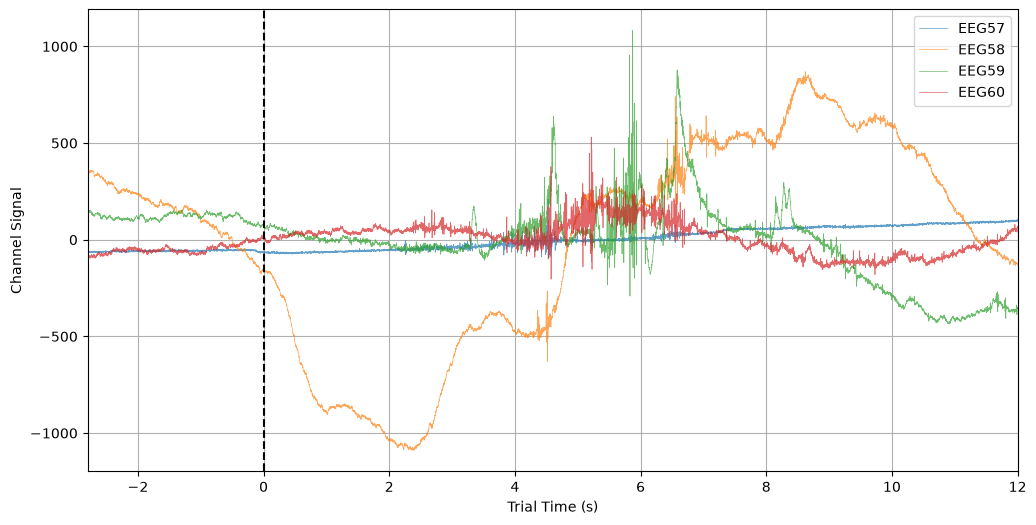

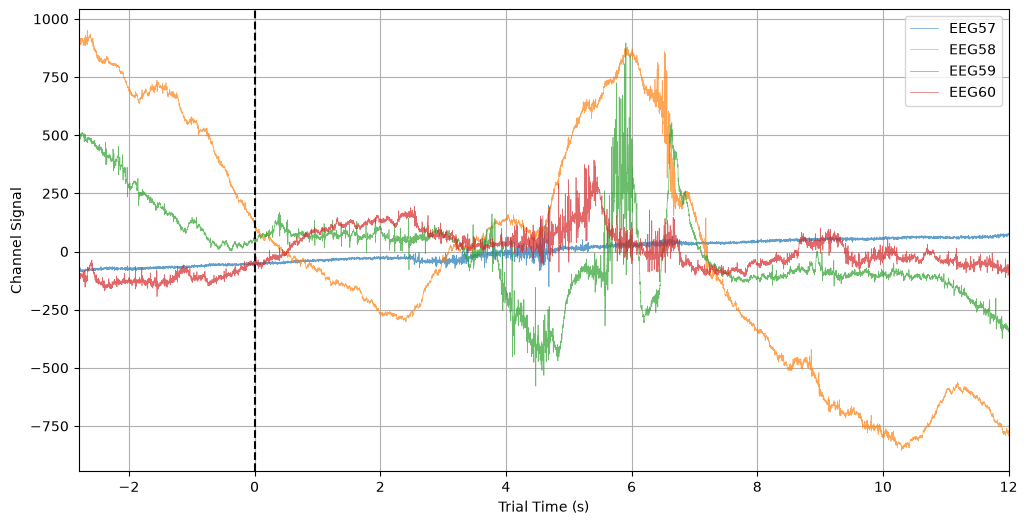

In [47]:
# check EEG channels for 2 trials

def EMG_plot(trial):
    plt.figure(figsize=(12, 6))
    for idx in range(4):
        plt.plot(EMG_data.times-2.8, EMG_channels[trial,idx,:],
                alpha=0.7,
                label=f"EEG{57+idx}",
                linewidth=0.5
        )
    plt.axvline(x=0,
                color='black',
                linestyle = '--'
                )
    plt.xlim(EMG_data.times[0] - 2.8, EMG_data.times[-1] - 2.8)
    plt.xlabel('Trial Time (s)')
    plt.ylabel('Channel Signal')
    plt.legend()
    plt.grid()
    plt.show()

EMG_plot(0)
EMG_plot(1)


For automatic theme detection, "darkdetect" has to be installed! You can install it with `pip install darkdetect`


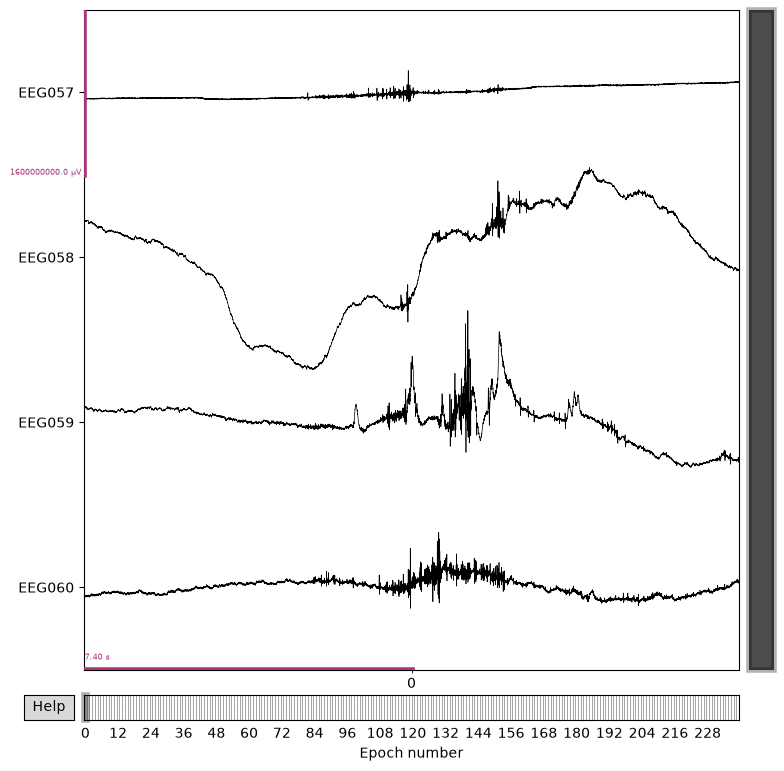

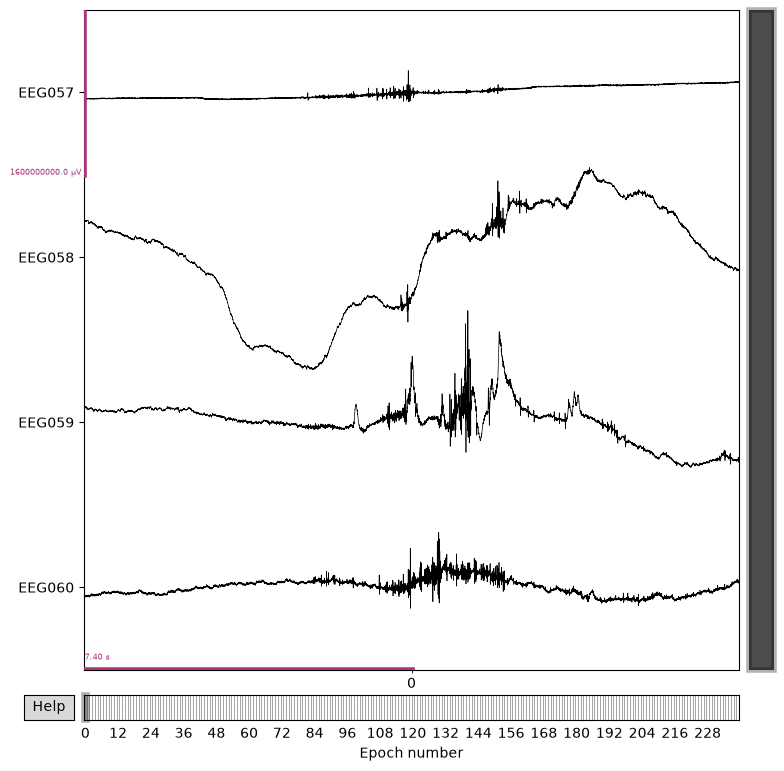

In [48]:
# using built in MNE function to plot data instead
EMG_data.plot(n_epochs=1,n_channels=4,picks=['EEG057','EEG058','EEG059','EEG060'],block=True,scalings=800,show=True,)

In [ ]:
# convert Epoch object back into a raw object, adding trials together end to end for each EMG channel
sfreq = EMG_data.info['sfreq']
ch_names = ['EEG057','EEG058','EEG059','EEG060']
ch_types = ["emg"] * 4
info = mne.create_info(ch_names=ch_names, ch_types=ch_types, sfreq=sfreq)      # define raw object info

n_epochs,n_channels,n_times = EMG_channels.shape
data = EMG_channels.transpose([1,0,2]).reshape((n_channels,n_epochs*n_times))  # reshape epochs array to join trials end to end

raw_epoch = mne.io.RawArray(data,info)                                         # create raw object 
print(raw_epoch.info)

In [ ]:
# modifying press_times array and original epoch trial times to align with raw data

# define empty arrays
tally_1 = np.zeros(shape=(1,5))
tally_2 = 0
press_times_shifted = np.zeros(shape=press_times.shape)
trial_cutoff_times = np.zeros(240) + 2.8

# shift press times per trial, stored in press_times_shifted
for trial_ind in range(0,240):
    press_times_shifted[trial_ind] = press_times[trial_ind,:] + tally_1
    trial_cutoff_times[trial_ind] = trial_cutoff_times[trial_ind] + tally_2
    tally_1 += 14.8
    tally_2 += 14.8

# flatten array into 1 dimension of button press times
press_times_shifted = press_times_shifted.flatten()

# converts seconds into sample index
samples_pt = np.round(np.array(press_times_shifted)*sfreq).astype(int)
samples_trial = np.round(np.array(trial_cutoff_times)*sfreq).astype(int)

# define button press and trial events object
bp_events = np.column_stack([
    samples_pt,
    np.zeros(len(samples_pt),dtype=int),
    np.zeros(len(samples_pt),dtype=int)
])

trial_events = np.column_stack([
    samples_trial,
    np.zeros(len(samples_trial),dtype=int),
    np.zeros(len(samples_trial),dtype=int)
])

# create epochs object around press times by [-1.5 0.5]
tfr_epochs = mne.Epochs(
    raw_epoch,
    bp_events,
    tmin=-0.5,
    tmax=0.5,
    baseline=None,
    preload=True,
)

baseline_epochs = mne.Epochs(
    raw_epoch,
    trial_events,
    tmin=-1.0,
    tmax=0.0,
    baseline=None,
    preload=True,
    verbose=False,
)

print(f'Epochs Object info:')
print('\n')
print(tfr_epochs.info)

In [ ]:
# assign variables for time frequency analysis
freqs = np.arange(5, 251, 2)
n_cycles = freqs / 10

# compute time frequnecy for epoched data
power = tfr_epochs.compute_tfr(
    method="morlet",
    freqs=freqs,
    n_cycles=n_cycles,
    picks=ch_names,
    average=True,
    return_itc=False,
)

# Extract pre-press baseline windows from the original EMG signals
baseline_tfr = baseline_epochs.compute_tfr(
    method="morlet",
    freqs=freqs,
    n_cycles=n_cycles,
    picks=ch_names,
    average=True,
    return_itc=False,
    verbose=False,
)

# Subtract the baseline mean for each channel and frequency
baseline_mean = baseline_tfr.data.mean(axis=-1, keepdims=True)
power.data -= baseline_mean


In [ ]:
# plot time frequency of all channels

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)
time_window = np.array([-0.4,0.1])

visible_times = (power.times >= time_window[0]) & (power.times <= time_window[1])
vlim = np.nanpercentile(np.abs(power.data[:, :, visible_times]), 80)

for ch_idx, ax in enumerate(axes.flat):
    image = ax.pcolormesh(
        power.times,
        power.freqs,
        power.data[ch_idx],
        shading="auto",
        cmap="jet",
    )
    ax.axvline(0, color="black", linestyle="--", linewidth=1)
    ax.set_title(ch_names[ch_idx])
    ax.set_xlabel("Time relative to button press (s)")
    ax.set_ylabel("Frequency (Hz)")
    ax.set_xlim(time_window[0],time_window[1])
    ax.set_ylim(0,250)
    fig.colorbar(image, ax=ax, label="Power change from baseline")

    image.set_clim(vmin=-vlim, vmax=vlim)

fig.suptitle("Average EMG time-frequency power (baseline: −1 to 0 s)")
fig.tight_layout()
plt.show()